In [18]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: ANYWIDGET_HMR=1


# Load Arina 4D-STEM Data
GPU-accelerated bitshuffle+LZ4 decompression. Auto-detects the best GPU backend (MPS on macOS, CUDA/Intel coming soon). Decompresses on the GPU and bins detector axes on the fly, so datasets larger than RAM can be loaded.
```python
from quantem.widget import IO

# Single file → 4D
result = IO.arina_file("master.h5", det_bin=2)

# Cherry-pick specific files → 5D
result = IO.arina_file(["scan_00.h5", "scan_03.h5"], det_bin=4)

# Whole folder → 5D
result = IO.arina_folder("/data/session/", det_bin=4)

# Filter by name, search subdirectories, merge multiple folders
result = IO.arina_folder("/data/", pattern="SnMoS2", recursive=True)
result = IO.arina_folder(["/data/day1/", "/data/day2/"], det_bin=8)
```

In [19]:
from quantem.widget import IO, Show2D, Show4DSTEM

## SnMoS2 — 2x2 detector binning

In [20]:
result = IO.arina_file(
    "/Users/macbook/data/guoliang/Show4DSTEM/20260208/SnMoS2s_001_master.h5",
    det_bin=2,
)
print(result)

load_arina: 262144 frames, det (192,192) → (96,96), 3.08s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
IOResult
  shape:      512 x 512 x 96 x 96
  dtype:      float32
  memory:     9.0 GB
  title:      SnMoS2s_001
  metadata:   41 fields


In [21]:
Show4DSTEM(result, title="SnMoS2 4D-STEM (2x binned)")

  to cpu: 0.01s (9.7 GB)
  auto_detect_center: 0.38s
  virtual image + frame: 0.01s
Show4DSTEM: 512x512x96x96 cpu, 0.65s total


Show4DSTEM(shape=(512, 512, 96, 96), sampling=(1.0 Å, 1.0 px), pos=(256, 256), title='SnMoS2 4D-STEM (2x binned)')

## Virtual bright field

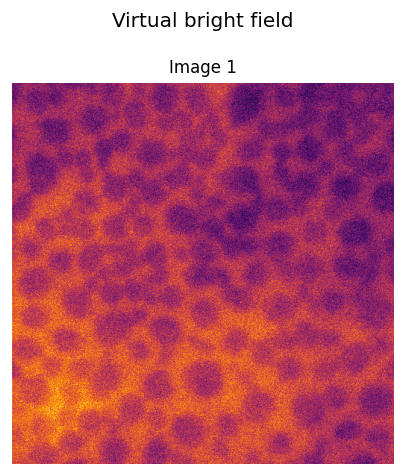

In [22]:
Show2D(result.sum(axis=(2, 3)), title="Virtual bright field")

## Center diffraction pattern

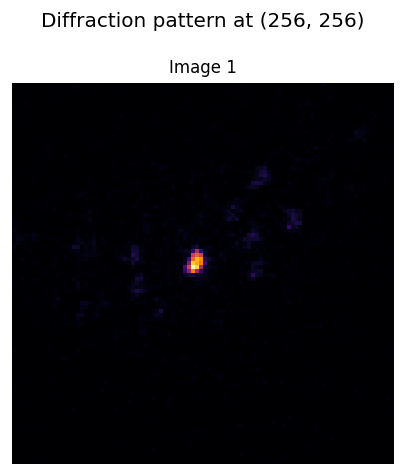

In [23]:
row, col = result.shape[0] // 2, result.shape[1] // 2
dp = result.data[row, col]
Show2D(dp, title=f"Diffraction pattern at ({row}, {col})", log_scale=True, show_fft=True)

## Korean sample — uint32, 65k frames

In [24]:
# data_kr = IO.arina_file(
#     "/Users/macbook/data/20251216_Korea_Sample_C1/KoreanSampleC1Bob_00_master.h5",
#     det_bin=2,
# )
# Show4DSTEM(data_kr, title="Korean Sample C1")

## Folder → 5D-STEM stack
Load all `*_master.h5` files in a session folder. Each file becomes one frame in a 5D tensor `(n_files, scan_r, scan_c, det_r, det_c)`. Files with missing chunks are automatically skipped.

In [25]:
folder = "/Users/macbook/data/20251216_Korea_Sample_C1/"
result5d = IO.arina_folder(folder, det_bin=8)
print(result5d)

[1/12] KoreanSampleC1Bob_00_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 1.43s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[2/12] KoreanSampleC1Bob_01_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.70s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[3/12] KoreanSampleC1Bob_02_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.56s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[4/12] KoreanSampleC1Bob_03_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.73s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[5/12] KoreanSampleC1Bob_04_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.71s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[6/12] KoreanSampleC1Bob_06_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.67s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[7/12] KoreanSampleC1Bob_07_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.68s
hot pixel filter: 4 pixels ze

## Inspect per-frame metadata
`describe()` prints a table of HDF5 metadata for each loaded file. By default (`diff=True`), only columns where values differ across frames are shown — useful for spotting what changed in a defocus or tilt series. Use `describe(diff=False)` to see everything, or pass `keys=["count_time", "photon_energy"]` for specific fields.

In [26]:
result5d.describe()  # diff=True by default — only shows columns that vary across frames

All selected metadata fields are identical across frames.
Use describe(diff=False) to see all fields.


In [27]:
Show4DSTEM(result5d, frame_dim_label="Scan", title="Korean Sample 5D")

  to mps: 0.21s (1.5 GB)
  auto_detect_center: 0.04s
  virtual image + frame: 0.02s
Show4DSTEM: 10x256x256x24x24 mps, 0.31s total


Show4DSTEM(shape=(10, 256, 256, 24, 24), sampling=(1.0 Å, 1.0 px), pos=(128, 128), scan=0, title='Korean Sample 5D')

## Filter by name
`pattern=` selects files whose name contains the string (case-insensitive). Only focal series files are loaded here.

In [28]:
result_focal = IO.arina_folder(folder, pattern="focal", det_bin=8)
print(result_focal)

[1/2] KoreanSampleC1Bobfocalseries_00_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.64s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[2/2] KoreanSampleC1Bobfocalseries_01_master.h5
  SKIPPED: Missing 3/7 chunk files for KoreanSampleC1Bobfocalseries_01_master.h5: ['KoreanSampleC1Bobfocalseries_01_data_000005.h5', 'KoreanSampleC1Bobfocalseries_01_data_000006.h5', 'KoreanSampleC1Bobfocalseries_01_data_000007.h5']
Skipped 1/2 files: ['KoreanSampleC1Bobfocalseries_01_master.h5']
IOResult
  shape:      1 x 256 x 256 x 24 x 24
  dtype:      float32
  memory:     144 MB
  title:      20251216_Korea_Sample_C1
  labels:     ['KoreanSampleC1Bobfocalseries_00']
  frames:     1 with metadata (41 fields each)


In [29]:
result_bob = IO.arina_folder(folder, pattern="Bob_0", det_bin=8)
print(result_bob)

[1/9] KoreanSampleC1Bob_00_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.70s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[2/9] KoreanSampleC1Bob_01_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.66s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[3/9] KoreanSampleC1Bob_02_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.52s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[4/9] KoreanSampleC1Bob_03_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.67s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[5/9] KoreanSampleC1Bob_04_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.69s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[6/9] KoreanSampleC1Bob_06_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.68s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[7/9] KoreanSampleC1Bob_07_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.71s
hot pixel filter: 4 pixels zeroed (5

## Cherry-pick specific files
Pass a list of paths to `IO.arina_file` to stack specific files into 5D. All files must have the same scan shape (raises `ValueError` otherwise).

In [30]:
result_pick = IO.arina_file([
    f"{folder}/KoreanSampleC1Bob_00_master.h5",
    f"{folder}/KoreanSampleC1Bob_04_master.h5",
    f"{folder}/KoreanSampleC1Bob_08_master.h5",
], det_bin=8)
print(result_pick)

[1/3] KoreanSampleC1Bob_00_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.64s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[2/3] KoreanSampleC1Bob_04_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.68s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[3/3] KoreanSampleC1Bob_08_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.66s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
IOResult
  shape:      3 x 256 x 256 x 24 x 24
  dtype:      float32
  memory:     432 MB
  title:      KoreanSampleC1Bob_00
  labels:     ['KoreanSampleC1Bob_00', 'KoreanSampleC1Bob_04', 'KoreanSampleC1Bob_08']
  frames:     3 with metadata (41 fields each)


## Recursive search
`recursive=True` searches subdirectories. Combine with `pattern=` to find specific samples across a data tree.

In [31]:
result_recursive = IO.arina_folder(
    "/Users/macbook/data/",
    recursive=True,
    pattern="SnMoS2",
    det_bin=8,
)
print(result_recursive)

[1/1] SnMoS2s_001_master.h5
load_arina: 262144 frames, det (192,192) → (24,24), 3.35s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
IOResult
  shape:      1 x 512 x 512 x 24 x 24
  dtype:      float32
  memory:     576 MB
  title:      data
  labels:     ['SnMoS2s_001']
  frames:     1 with metadata (41 fields each)


## Multiple folders
Pass a list of folder paths to merge scans from multiple sessions. `max_files=` caps the total loaded (default 50).

In [32]:
result_multi = IO.arina_folder(
    ["/Users/macbook/data/20251216_Korea_Sample_C1/",
     "/Users/macbook/data/guoliang/Show4DSTEM/20260208/"],
    det_bin=8,
    max_files=3,
)
print(result_multi)

Found 13 master files, loading first 3 (set max_files=0 to load all)
[1/3] KoreanSampleC1Bob_00_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 1.22s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[2/3] KoreanSampleC1Bob_01_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.66s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
[3/3] KoreanSampleC1Bob_02_master.h5
load_arina: 65536 frames, det (192,192) → (24,24), 0.54s
hot pixel filter: 4 pixels zeroed (5.0σ threshold)
IOResult
  shape:      3 x 256 x 256 x 24 x 24
  dtype:      float32
  memory:     432 MB
  title:      20251216_Korea_Sample_C1
  labels:     ['KoreanSampleC1Bob_00', 'KoreanSampleC1Bob_01', 'KoreanSampleC1Bob_02']
  frames:     3 with metadata (41 fields each)


## Free GPU memory
4D-STEM datasets are large (1–10+ GB). When switching between datasets, call `free()` on the widget to release the MPS tensor, then delete the IOResult. Without this, memory accumulates and eventually crashes the kernel.

In [33]:
import torch
# w.free()        # deletes MPS tensor, runs gc, flushes cache
# del result       # free the source numpy array
print(f"MPS memory: {torch.mps.current_allocated_memory() / 1e9:.1f} GB allocated")

MPS memory: 3.0 GB allocated
